# Temas Tratados en el Trabajo Práctico 2

* Conceptos de Búsqueda no Informada y Búsqueda Informada.

* Concepto de Heurística.

* Abstracción de Problemas como Gráficos de Árbol.

* Estrategias de Búsqueda no Informada: Primero en Amplitud, Primero en Profundidad y Profundidad Limitada.

* Estrategias de Búsqueda Informada: Búsqueda Voraz, Costo Uniforme, A*.


## Ejercicios Teóricos

1. ¿Qué diferencia hay entre una estrategia de búsqueda Informada y una estrategia de búsqueda No Informada?

2. ¿Qué es una heurística y para qué sirve?

3. ¿Es posible que un algoritmo de búsqueda no tenga solución?

4. Describa en qué secuencia será recorrido el Árbol de Búsqueda representado en la imagen cuando se aplica un Algoritmo de Búsqueda con la estrategia:

        4.1 Primero en Amplitud.

        4.2 Primero en Profundidad.

        4.3 Primero en Profundidad con Profundidad Limitada Iterativa (comenzando por un nivel de profundidad 1).

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1IJDEKWhfMEzXnzr28RgTNOuKBER2NsuP"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

ModuleNotFoundError: No module named 'requests'

Muestre la respuesta en una tabla, indicando para cada paso que da el agente el nodo que evalúa actualmente y los que están en la pila/cola de expansión según corresponda.

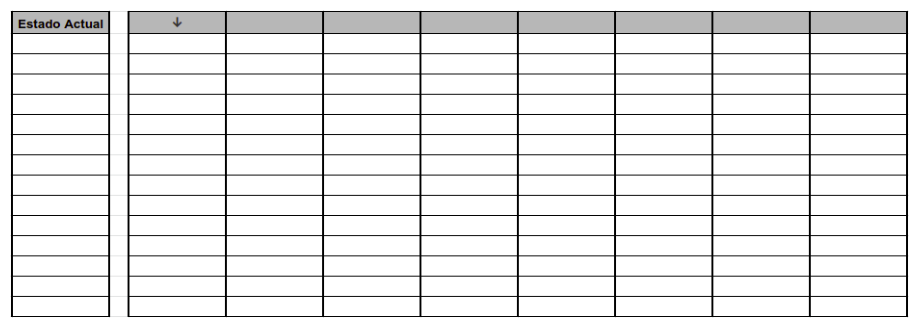

In [ ]:
url = "https://drive.google.com/uc?export=view&id=1fW_BgT5muzQffMVRcIiB2mM2Zf66Nb-m"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar con figura más grande
plt.figure(figsize=(img.width / 80, img.height / 80))  # ajustá el divisor según densidad deseada
plt.imshow(img)
plt.axis('off')
plt.show()

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

5. Represente el tablero mostrado en la imágen como un árbol de búsqueda y a continuación programe un agente capaz de navegar por el tablero para llegar desde la casilla I a la casilla F utilizando:

        5.1 La estrategia Primero en Profundidad.

        5.2 La estrategia Avara.

        5.3 La estrategia A*.

Considere los siguientes comportamientos del agente:

* El agente no podrá moverse a las casillas siguientes si las separa una pared.

* La heurística empleada en el problema es la Distancia de Manhattan hasta la casilla objetivo (el menor número de casillas adyacentes entre la casilla actual y la casilla objetivo).

* El costo de atravesar una casilla es de 1, a excepción de la casilla W, cuyo costo al atravesarla es 30.

* En caso de que varias casillas tengan el mismo valor para ser expandidas, el algoritmo eligirá en orden alfabético las casillas que debe visitar.

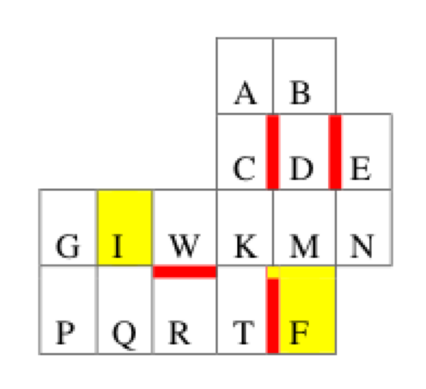

In [6]:
url = "https://drive.google.com/uc?export=view&id=1FajYiBQ507o6yiE7MndL-PQXyoyELtuD"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')
plt.show()

6. Desarrolle un agente que emplee una estrategia de búsqueda A* para ir de una casilla a otra evitando la pared representada, pudiendo seleccionar ustedes mismos el inicio y el final. Muestre en una imagen el camino obtenido.

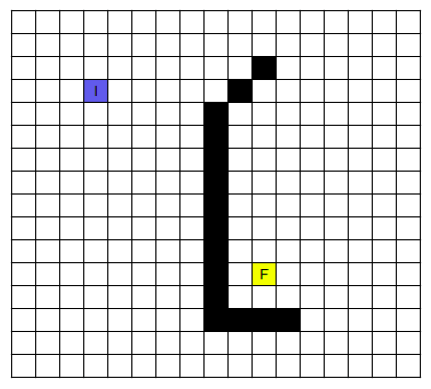

In [7]:
url = "https://drive.google.com/uc?export=view&id=1fD2Ws5oqFU9_RTj-yX9BIvslXJiqcLCZ"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')
plt.show()

# Prompt utilizado

Rol: Actúa como un Desarrollador Senior de Python especializado en algoritmos de búsqueda y visualización de datos.

Tarea: Escribe un script en Python utilizando numpy y matplotlib que implemente el algoritmo A* (A-Estrella) en una cuadrícula interactiva.

Especificaciones del Entorno:

La cuadrícula debe ser exactamente de 17 columnas por 16 filas.

Debes crear una pared (obstáculos) en las siguientes coordenadas (fila, columna): (2, 10), (3, 9), (4, 8), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (10, 8), (11, 8), (12, 8), (13, 8), (13, 9), (13, 10), (13, 11). El resto del espacio está libre.

Usa la Distancia de Manhattan como heurística para el algoritmo A* (movimientos ortogonales únicamente).

Interactividad requerida (Matplotlib GUI):

El programa debe abrir una ventana interactiva.

Primer clic del usuario: Selecciona el punto de Inicio (márcalo con un cuadrado azul grande).

Segundo clic del usuario: Selecciona el punto de Fin (márcalo con un cuadrado amarillo grande) e inmediatamente ejecuta el algoritmo A*. Dibuja el camino encontrado con una línea roja gruesa.

Tercer clic del usuario: Reinicia el tablero por completo, limpia el camino y toma ese clic como el nuevo punto de Inicio.

Añade validaciones para evitar que el usuario haga clic fuera de la cuadrícula o sobre una pared.

Restricciones: No utilices pygame ni otras librerías externas para la interfaz gráfica, todo debe manejarse con el sistema de eventos nativo de matplotlib (button_press_event). El código debe estar en un solo bloque, bien comentado y listo para ejecutarse.

# Codigo del Laberinto A-Estrella

INTERFAZ INICIADA:
1. Haz clic en una casilla blanca para elegir el INICIO.
2. Haz clic en otra casilla blanca para elegir el FIN y calcular el camino.
3. Haz clic de nuevo para reiniciar.



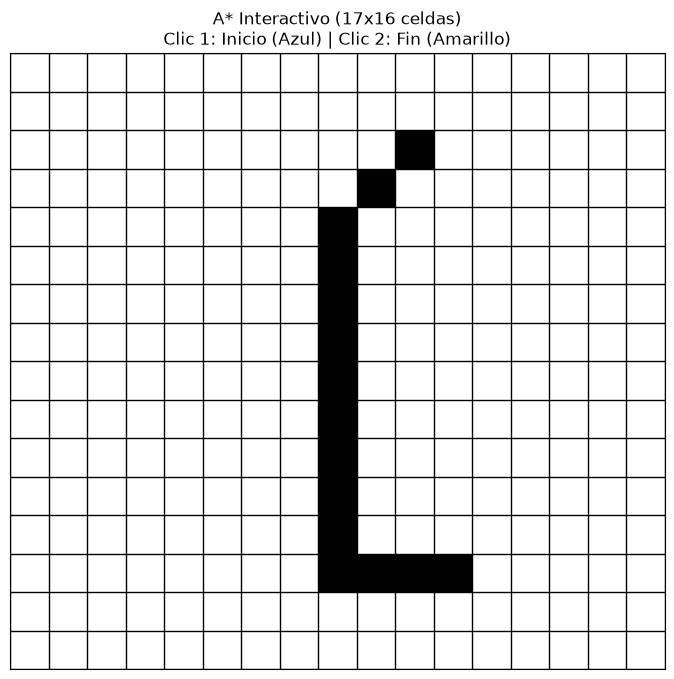

In [7]:
import heapq
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Definición del Entorno (CORREGIDO) ---
def crear_rejilla():
    # Cuadrícula de 16 filas y 17 columnas (17x16)
    rejilla = np.zeros((16, 17))
    
    # Coordenadas exactas de la pared basadas en tu imagen original
    obstaculos = [
        # Punta superior en diagonal
        (2, 10), 
        (3, 9),  
        # Tallo vertical
        (4, 8), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (10, 8), (11, 8), (12, 8), (13, 8), 
        # Base horizontal inferior
        (13, 9), (13, 10), (13, 11) 
    ]
    
    for r, c in obstaculos:
        rejilla[r, c] = 1 # Marcar como obstáculo (1)
        
    return rejilla

# --- 2. Algoritmo A* ---
def heuristica(a, b):
    # Distancia Manhattan
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def obtener_vecinos(actual, rejilla):
    vecinos = []
    r, c = actual
    movimientos = [(0, 1), (0, -1), (1, 0), (-1, 0)] # Arriba, Abajo, Derecha, Izquierda
    
    for dr, dc in movimientos:
        nr, nc = r + dr, c + dc
        # Usamos rejilla.shape para que se adapte dinámicamente a 16x17
        if 0 <= nr < rejilla.shape[0] and 0 <= nc < rejilla.shape[1]:
            if rejilla[nr, nc] == 0: # Si no es pared
                vecinos.append((nr, nc))
    return vecinos

def a_estrella(rejilla, inicio, fin):
    cola_prioridad = []
    heapq.heappush(cola_prioridad, (0, inicio))
    papiros = {inicio: None}
    coste_actual = {inicio: 0}
    
    while cola_prioridad:
        _, actual = heapq.heappop(cola_prioridad)
        
        if actual == fin:
            break
            
        for vecino in obtener_vecinos(actual, rejilla):
            nuevo_coste = coste_actual[actual] + 1
            if vecino not in coste_actual or nuevo_coste < coste_actual[vecino]:
                coste_actual[vecino] = nuevo_coste
                prioridad = nuevo_coste + heuristica(vecino, fin)
                heapq.heappush(cola_prioridad, (prioridad, vecino))
                papiros[vecino] = actual
                
    camino = []
    if fin in papiros:
        curr = fin
        while curr:
            camino.append(curr)
            curr = papiros[curr]
        camino.reverse()
    return camino

# --- 3. Interfaz Interactiva con Matplotlib ---
class LaberintoInteractivo:
    def __init__(self, rejilla):
        self.rejilla = rejilla
        self.inicio = None
        self.fin = None
        
        # Configurar la figura adaptada al tamaño (un poco más ancha)
        self.fig, self.ax = plt.subplots(figsize=(9, 8))
        self.fig.canvas.manager.set_window_title('A* Interactivo (17x16) - Haz clic para jugar')
        
        # Dibujar la cuadrícula inicial
        self.dibujar_tablero()
        
        # Conectar el evento de clic del ratón
        self.fig.canvas.mpl_connect('button_press_event', self.al_hacer_clic)
        
        print("INTERFAZ INICIADA:")
        print("1. Haz clic en una casilla blanca para elegir el INICIO.")
        print("2. Haz clic en otra casilla blanca para elegir el FIN y calcular el camino.")
        print("3. Haz clic de nuevo para reiniciar.\n")
        
        plt.show()

    def dibujar_tablero(self):
        self.ax.clear()
        self.ax.imshow(self.rejilla, cmap='Greys', interpolation='nearest', origin='upper')
        
        # Configurar líneas de la cuadrícula dinámicamente según el shape
        filas = self.rejilla.shape[0]
        columnas = self.rejilla.shape[1]
        
        self.ax.set_xticks(np.arange(-0.5, columnas, 1))
        self.ax.set_yticks(np.arange(-0.5, filas, 1))
        self.ax.grid(which='major', color='black', linestyle='-', linewidth=1)
        self.ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
        self.ax.set_title('A* Interactivo (17x16 celdas)\nClic 1: Inicio (Azul) | Clic 2: Fin (Amarillo)', fontsize=12)

    def al_hacer_clic(self, evento):
        if evento.xdata is None or evento.ydata is None:
            return
            
        columna = int(round(evento.xdata))
        fila = int(round(evento.ydata))
        
        if not (0 <= fila < self.rejilla.shape[0] and 0 <= columna < self.rejilla.shape[1]):
            return
            
        if self.rejilla[fila, columna] == 1:
            print("Has hecho clic en una pared. Elige una casilla libre.")
            return

        if self.inicio is None:
            self.inicio = (fila, columna)
            self.ax.plot(columna, fila, 'bs', markersize=20, label='Inicio')
            self.fig.canvas.draw()
            print(f"Inicio seleccionado en: {self.inicio}")
            
        elif self.fin is None:
            self.fin = (fila, columna)
            self.ax.plot(columna, fila, 'ys', markersize=20, label='Fin')
            print(f"Fin seleccionado en: {self.fin}. Calculando ruta...")
            
            camino = a_estrella(self.rejilla, self.inicio, self.fin)
            
            if camino:
                camino_y, camino_x = zip(*camino)
                self.ax.plot(camino_x, camino_y, 'r-', linewidth=4, label='Camino A*')
                print(f"¡Camino encontrado! Longitud: {len(camino)} pasos.")
            else:
                self.ax.set_title("¡No hay camino posible!", color='red')
                print("No se encontró ningún camino.")
                
            self.fig.canvas.draw()
            
        else:
            self.inicio = (fila, columna)
            self.fin = None
            self.dibujar_tablero()
            self.ax.plot(columna, fila, 'bs', markersize=20, label='Inicio')
            self.fig.canvas.draw()
            print(f"\n--- Tablero reiniciado --- \nNuevo Inicio seleccionado en: {self.inicio}")

# --- Bloque Principal ---
if __name__ == "__main__":
    grid = crear_rejilla()
    app = LaberintoInteractivo(grid)

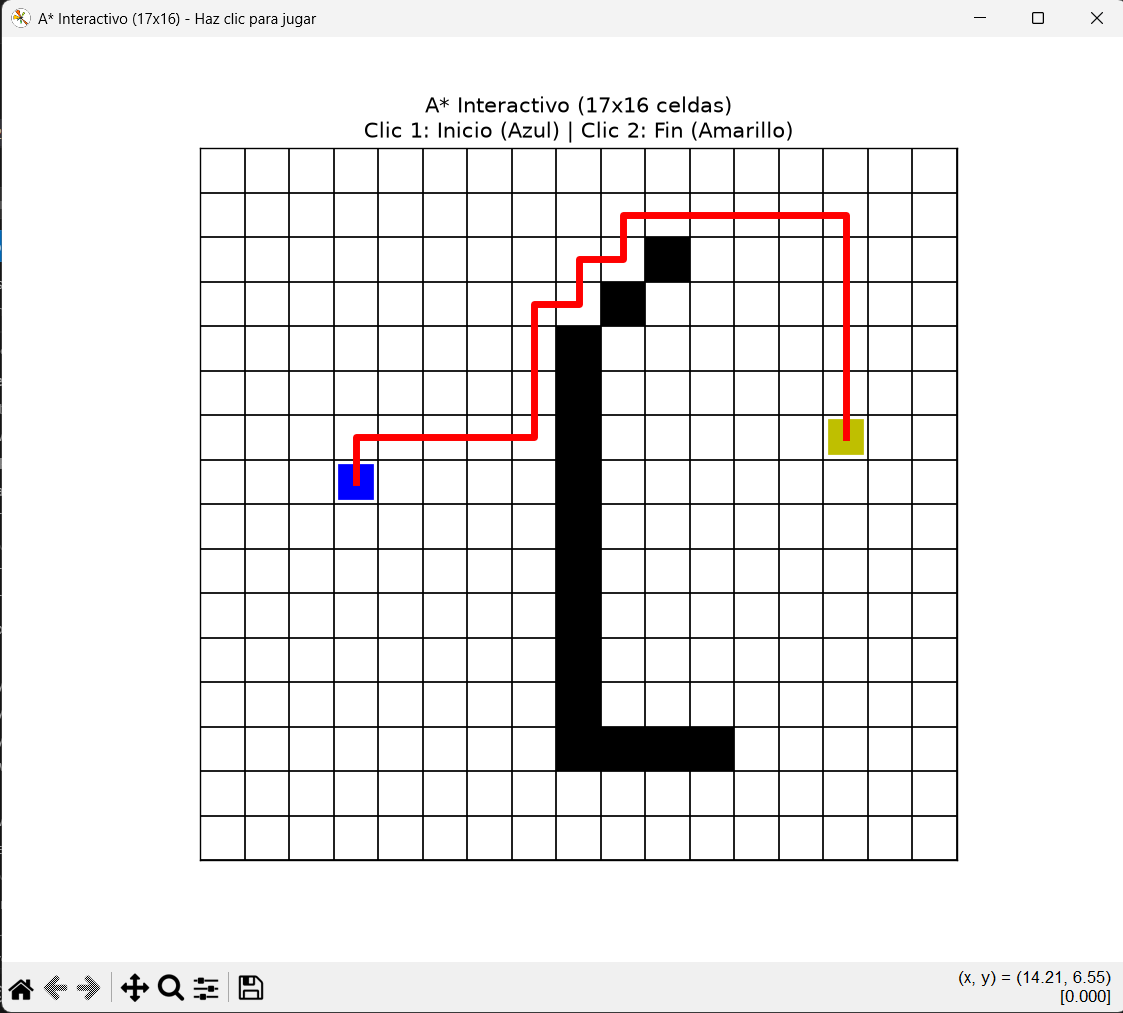

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)